In [39]:
%matplotlib inline

In [40]:
import xtrack as xt
import xpart as xp
import xobjects as xo
import matplotlib.pyplot as plt
from scipy.constants import c as clight

import numpy as np

In [41]:
p0_carbon = xt.Particles('Carbon-12', q0=6)
p0_helium = xt.Particles('Helium-4', q0=2)

In [42]:
p0_carbon.pdg_id, p0_helium.pdg_id

(array([1000060120]), array([1000020040]))

In [43]:
mass_ratio_he_ca = p0_helium.mass0 / p0_carbon.mass0
charge_ratio_he_ca = p0_helium.q0 / p0_carbon.q0

In [44]:
env = xt.load('./pimm.json')
env.vars.load('./pimm_strengths.json')

line = env.ring
# line.configure_bend_model(core='bend-kick-bend')#num_multipole_kicks=5)
line.configure_bend_model(num_multipole_kicks=5)
line.set_particle_ref('Carbon-12', q0=6, kinetic_energy0=200e6 * 12)

tw4d = line.twiss4d()
eta = tw4d.slip_factor
line_length = tw4d.line_length

line['vrf'] = 0 # Debunched beam
line['frf'] = 1 / tw4d.t_rev0 # h=1

Loading line from dict:   0%|          | 0/86 [00:00<?, ?it/s]

In [45]:
opt = line.match(
    solve=False, # <- prepare the match without running it
    chrom=False,
    method='4d',
    vary=[
        xt.Vary('kqfa', limits=(0, 10),  step=1e-3),
        xt.Vary('kqfb', limits=(0, 10),  step=1e-3),
        xt.Vary('kqd', limits=(-10, 0), step=1e-3),
    ],
    targets=[
        xt.TargetSet(qx=1.665, qy=1.72, tol=1e-4),
        xt.TargetSet(dx=0, at='mid.lss.0', tol=2e-3),
        xt.TargetSet(dx=0, at='mid.lss.1', tol=2e-3),
    ]
)
opt.step(20)
opt.target_status()

                                             
Optimize - start penalty: 0.2504                            
Matching: model call n. 13 penalty = 1.5671e-05              
Optimize - end penalty:  1.56713e-05                            
Target status:               nalty = 1.5671e-05              
id state tag          tol_met       residue   current_val    target_val description                                 
0  ON    qx              True    3.4103e-07         1.665         1.665 'qx', val=1.665, tol=0.0001, weight=10      
1  ON    qy              True   2.50955e-08          1.72          1.72 'qy', val=1.72, tol=0.0001, weight=10       
2  ON    mid.lss.0_dx    True  -1.07975e-06  -1.07975e-06             0 ('dx', 'mid.lss.0'), val=0, tol=0.002, w ...
3  ON    mid.lss.1_dx    True   -1.0831e-06   -1.0831e-06             0 ('dx', 'mid.lss.1'), val=0, tol=0.002, w ...


In [46]:
opt = line.match_knob(
    run=False, # <- prepare the match without running it
    knob_name='chrom_x',
    knob_value_start=tw4d.dqx,
    knob_value_end=-1,
    method='4d',
    vary=[
        xt.VaryList(['ksf', 'ksd'], step=1e-3),
    ],
    targets=[
        xt.TargetSet(dqx=-1., dqy=tw4d.dqy, tol=1e-4),
    ]
)
opt.step(20)
opt.target_status()
opt.generate_knob()

                                             
Optimize - start penalty: 0.9775                            
Matching: model call n. 11 penalty = 2.2800e-07              
Optimize - end penalty:  2.27999e-07                            
Target status:               nalty = 2.2800e-07              
id state tag tol_met       residue   current_val    target_val description                                 
0  ON    dqx    True  -2.27999e-07            -1            -1 'dqx', val=-1, tol=0.0001, weight=1         
1  ON    dqy    True  -1.55431e-10   -0.00991197   -0.00991197 'dqy', val=-0.00991197, tol=0.0001, weig ...
Generated knob:  chrom_x                       


In [47]:
env.new('extr_septum', xt.Marker)
env.new('septum_aperture', xt.LimitRect, min_x=-0.1, max_x=0.1, min_y=-0.1, max_y=0.1),

line.insert(['extr_septum', 'septum_aperture'], at=0)



Slicing line:   0%|          | 0/109 [00:00<?, ?it/s]

In [48]:
env['kse'] = 3.

In [49]:
line['chrom_x']=0
line.twiss4d().dqx

np.float64(-0.01337962665994253)

In [50]:
x_gen = np.linspace(0, 1e-2, 20)
p = line.build_particles(x=x_gen, px=0, y=0, py=0, zeta=0, delta=0)
p_he = line.build_particles(x=x_gen, px=0, y=0, py=0, zeta=0, delta=0,
                            mass_ratio=mass_ratio_he_ca, charge_ratio=charge_ratio_he_ca)

In [51]:
line.track(p, num_turns=1000, turn_by_turn_monitor=True,
           with_progress=True)
rec = line.record_last_track
line.track(p_he, num_turns=1000, turn_by_turn_monitor=True,
           with_progress=True)
rec_he = line.record_last_track

Tracking:   0%|          | 0/1000 [00:00<?, ?it/s]

Tracking:   0%|          | 0/1000 [00:00<?, ?it/s]

In [52]:
x_septum = 3.5e-2

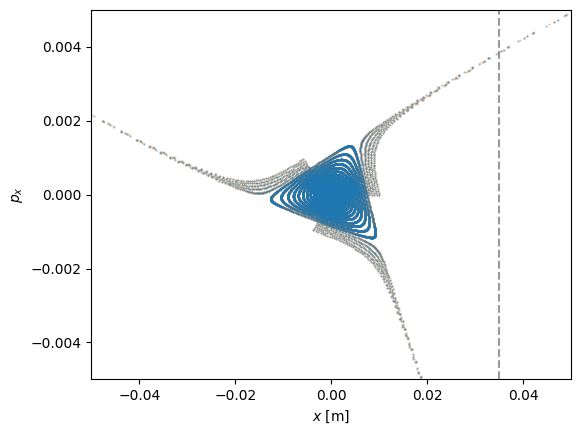

In [53]:
# Plot turn-by-turn data
plt.figure()
plt.plot(rec_he.x.T, rec_he.px.T, '.', markersize=1, color='C1', alpha=0.5)
plt.plot(rec.x.T, rec.px.T, '.', markersize=1, color='C0', alpha=0.5)
plt.xlabel(r'$x$ [m]'); plt.ylabel(r'$p_x$'), plt.xlim(-5e-2, 5e-2); plt.ylim(-5e-3, 5e-3)
plt.axvline(x=x_septum, color='k', alpha=0.4, linestyle='--')
plt.subplots_adjust(left=.15)

### Build a matched beam distribution (carbon)

In [54]:
num_particles = 3000
beam_intensity = 1e10 # p+

# Generate Gaussian distribution in normalized phase space
x_norm = np.random.normal(size=num_particles)
px_norm = np.random.normal(size=num_particles)
y_norm = np.random.normal(size=num_particles)
py_norm = np.random.normal(size=num_particles)

# Generate Gaussian momentum distribution (rms spread 5e-4)
delta = 5e-4 * np.random.normal(size=num_particles)

# Particles arrival time spread over one turn
zeta = np.random.uniform(size=num_particles) * line.get_length()

# Assemble Particles object
p0_carbon = line.build_particles(
    x_norm=x_norm, px_norm=px_norm, 
    y_norm=y_norm, py_norm=py_norm,
    delta=delta,
    zeta=zeta,
    method='4d',
    weight=beam_intensity / num_particles,
    nemitt_x=1.e-6, nemitt_y=1e-6,
)



In [55]:
### Build a matched beam distribution (Helium)
num_particles = 3000
beam_intensity = 1e10 # p+

# Generate Gaussian distribution in normalized phase space
x_norm = np.random.normal(size=num_particles)
px_norm = np.random.normal(size=num_particles)
y_norm = np.random.normal(size=num_particles)
py_norm = np.random.normal(size=num_particles)

# Generate Gaussian momentum distribution (rms spread 5e-4)
delta = 5e-4 * np.random.normal(size=num_particles)

# Particles arrival time spread over one turn
zeta = np.random.uniform(size=num_particles) * line.get_length()

# Assemble Particles object
p0_helium = line.build_particles(
    x_norm=x_norm, px_norm=px_norm, 
    y_norm=y_norm, py_norm=py_norm,
    delta=delta,
    zeta=zeta,
    method='4d',
    weight=beam_intensity / num_particles,
    nemitt_x=0.1e-6, nemitt_y=1.e-6,
)

### Define time-dependent behavior of extraction sextupoles

In [56]:
line.functions['fun_xsext'] = xt.FunctionPieceWiseLinear(x=[0, 0.1e-3, 0.5e-3], y=[0, 0, 1.])

line.ref['kse'] *= line.functions['fun_xsext'](line.vars['t_turn_s'])

# Inspect the expression
line.ref['kse']._expr

(3.0 * f['fun_xsext'](vars['t_turn_s']))

In [57]:
line['septum_aperture'].max_x = x_septum

In [58]:
ctx = xo.ContextCpu(omp_num_threads='auto')
line.build_tracker(_context=ctx)

In [59]:
# User-defined quantity to be logged
def measure_intensity(line, particles):
    mask_alive = particles.state > 0
    intensity = np.sum(particles.weight[mask_alive])
    return intensity

log = xt.Log('kse',              # vars to be logged
             intensity=measure_intensity) # user-defined function to be logged

In [60]:
line.enable_time_dependent_vars = True

In [61]:
p = p0_carbon.copy()
line.track(p, num_turns=5000, with_progress=True,
           log=log)

Tracking:   0%|          | 0/5000 [00:00<?, ?it/s]

Text(0, 0.5, 'Intensity [$p^+$]')

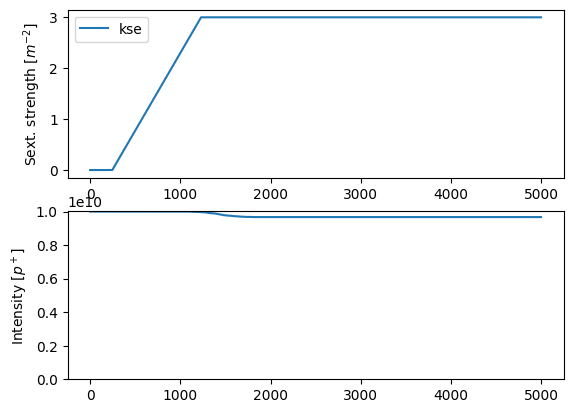

In [62]:
plt.figure()

ax1 = plt.subplot(2,1,1)
plt.plot(line.log_last_track['kse'], label='kse')
plt.ylabel('Sext. strength [$m^{-2}$]')
plt.legend()

ax2 = plt.subplot(2,1,2, sharex=ax1)
plt.plot(line.log_last_track['intensity'])
plt.ylim(bottom=0)
plt.ylabel('Intensity [$p^+$]')

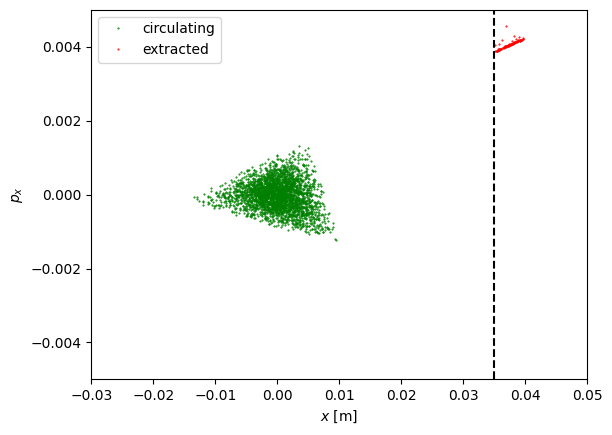

In [63]:
plt.figure()
mask_alive = p.state>0
mask_lost = ~mask_alive
plt.plot(p.x[mask_alive], p.px[mask_alive],
         '.', markersize=1, color='green', label='circulating')
plt.plot(p.x[mask_lost], p.px[mask_lost],
         '.', markersize=1, color='red', label='extracted')
plt.xlabel('$x$ [m]'); plt.ylabel('$p_x$')
plt.axvline(x=line['septum_aperture'].max_x, color='k', ls='--')
plt.xlim(-0.03, 0.05); plt.ylim(-5e-3, 5e-3)
plt.legend()
plt.show()

### Introduce transverse excitation to control the spill
We build a custom beam element that excites the beam with a sinusoidal function **of time**

In [64]:
class SpillExcitation:
    def __init__(self):
        
        self.amplitude = 0
        self.tune = 0
        self.f_rev = 1 / tw4d.t_rev0

    def track(self, p):

        f_excit = self.tune * self.f_rev

        # Time of arrival corrected for delay within the turn
        t_particle_pass = (p.at_turn[p.state > 0] / self.f_rev
                              - p.zeta[p.state > 0] / p.beta0[0] / clight)

        p.px[p.state > 0] += (
            self.amplitude * np.sin(2 * np.pi * f_excit * t_particle_pass))

line.insert('spill_exc', SpillExcitation(), at=0)


Slicing line:   0%|          | 0/111 [00:00<?, ?it/s]

Use the amplitude and the frequency of the excitation to control the spill

In [65]:
line.functions['fun_excit'] = xt.FunctionPieceWiseLinear(
    x=[0, 0.5e-3, 0.7e-3,    4e-3],
    y=[0, 0,       1e-5,   3.2e-5])
line.functions['fun_freq'] = xt.FunctionPieceWiseLinear(
    x=[0,     0.5e-3,  1.5e-3, 2.5e-3],
    y=[0.6615 ,0.6615, 0.6625, 0.663])

line.vars['ampl_excit'] = line.functions['fun_excit'](line.ref['t_turn_s'])
line.vars['freq_excit'] = line.functions['fun_freq'](line.ref['t_turn_s'])

line['spill_exc'].amplitude = env.ref['ampl_excit']
line['spill_exc'].tune = env.ref['freq_excit']

In [66]:
# Reset simulation time
line.vars['t_turn_s'] = 0
# Back to initial particles distribution


In [67]:
log = xt.Log(
    'kse', 't_turn_s', # vars to be logged
    'ampl_excit', 'freq_excit',
    intensity=measure_intensity)       # user-defined functions to be logged

In [76]:
line.enable_time_dependent_vars = False
line['chrom_x']=-4
line.twiss4d().dqx

The line has collective elements.
In the twiss computation collective elements are replaced by drifts


np.float64(-3.9571002221631675)

In [ ]:
line.enable_time_dependent_vars = True
p = p0_carbon.copy()
line.track(p, num_turns=5000, with_progress=True,
           log=log)
log_carbon = line.log_last_track

Tracking:   0%|          | 0/5000 [00:00<?, ?it/s]

In [ ]:
line.enable_time_dependent_vars = True
p = p0_helium.copy()
line.track(p, num_turns=5000, with_progress=True,
           log=log)
log_helium = line.log_last_track

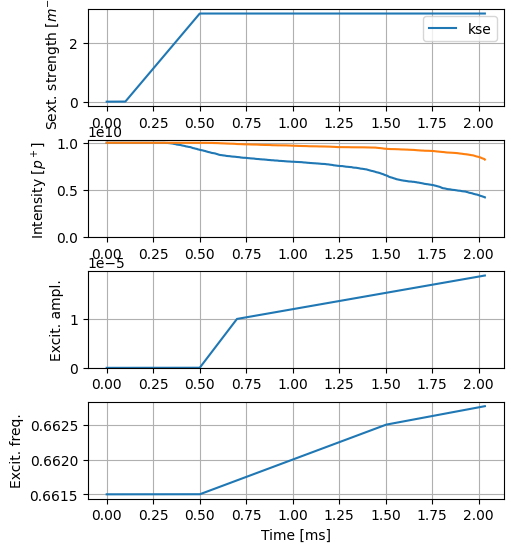

In [75]:
plt.figure(figsize=(6.4, 4.8*1.2))

t_ms = np.array(log_carbon['t_turn_s']) * 1e3

ax1 = plt.subplot(4,1,1)
plt.plot(t_ms, log_carbon['kse'], label='kse')
plt.ylabel('Sext. strength [$m^{-2}$]')
plt.legend()
plt.grid()

ax2 = plt.subplot(4,1,2, sharex=ax1)
plt.plot(t_ms, log_carbon['intensity'])
plt.plot(t_ms, log_helium['intensity'])
plt.ylim(bottom=0)
plt.ylabel('Intensity [$p^+$]')
plt.grid()

ax3 = plt.subplot(4,1,3, sharex=ax1)
plt.plot(t_ms, log_carbon['ampl_excit'])
plt.ylim(bottom=0)
plt.ylabel('Excit. ampl.')
plt.grid()

ax3 = plt.subplot(4,1,4, sharex=ax1)
plt.plot(t_ms, log_carbon['freq_excit'])
plt.ylabel('Excit. freq.')
plt.xlabel('Time [ms]')
plt.grid()

plt.subplots_adjust(top=.95, bottom=.1, left=.25, hspace=.35)